In [1]:

pip install pythonnet pandas numpy scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:

import clr
import sys
import os

dwsimpath = r"C:\Users\HP\AppData\Local\DWSIM6"
sys.path.append(dwsimpath)

try:
    clr.AddReference(os.path.join(dwsimpath, "CapeOpen.dll"))
    clr.AddReference(os.path.join(dwsimpath, "DWSIM.Automation.dll"))
    clr.AddReference(os.path.join(dwsimpath, "DWSIM.Interfaces.dll"))
    clr.AddReference(os.path.join(dwsimpath, "DWSIM.GlobalSettings.dll"))
    clr.AddReference(os.path.join(dwsimpath, "DWSIM.SharedClasses.dll"))
    clr.AddReference(os.path.join(dwsimpath, "DWSIM.Thermodynamics.dll"))
    clr.AddReference(os.path.join(dwsimpath, "DWSIM.UnitOperations.dll"))
    print("Libraries loaded successfully.")
except Exception as e:
    print(f"FAILED to load libraries. Error: {e}")



Libraries loaded successfully.


In [3]:
try:
    from DWSIM.Automation import Automation2
    print("SUCCESS: Automation class imported.")
except ImportError as e:
    print(f"IMPORT ERROR: {e}")

SUCCESS: Automation class imported.


In [4]:
import clr
import sys
import os
import pythoncom
pythoncom.CoInitialize()
dwsimpath = r"C:\Users\HP\AppData\Local\DWSIM6"
sys.path.append(dwsimpath)
clr.AddReference("DWSIM.Automation")
clr.AddReference("DWSIM.GlobalSettings")

from DWSIM.Automation import Automation3
from DWSIM.GlobalSettings import Settings

Settings.AppPath = dwsimpath

print("Booting DWSIM Engine...")
try:
    interf = Automation3()
    print("Engine booted successfully.")
except Exception as e:
    print(f"FATAL ENGINE CRASH: {e}")
    sys.exit()

flowsheet_path = r"E:\New Folder\Proj\FOSSEE.dwxmz"

print("Loading flowsheet into memory...")
sim = interf.LoadFlowsheet(flowsheet_path)

if sim is None:
    print("FATAL ERROR: Could not load the flowsheet. Check your path.")
else:
    print("SUCCESS: Flowsheet loaded.")
    
    try:
        feed = sim.GetFlowsheetSimulationObject("Feed").GetAsObject()
        column = sim.GetFlowsheetSimulationObject("DCOL-1").GetAsObject()
        
        print(f"Target Acquired: {feed.GetDisplayName()}")
        print(f"Target Acquired: {column.GetDisplayName()}")
        
    except Exception as e:
        print(f"Error targeting objects: {e}")

Booting DWSIM Engine...
Engine booted successfully.
Loading flowsheet into memory...
SUCCESS: Flowsheet loaded.
Target Acquired: Material Stream
Target Acquired: Distillation Column


In [ ]:
print("--- DIAGNOSTIC: THE MATRIX KEYS ---")
try:
    keys = list(column.Specs.Keys)
    
    if not keys:
        print("Dictionary is empty or inaccessible.")
    else:
        print("Discovered Matrix Specification Keys:")
        for key in keys:
            print(f"- {key}")
            
except Exception as e:
    print(f"Error reading dictionary keys: {e}")

--- DIAGNOSTIC: THE MATRIX KEYS ---
Discovered Matrix Specification Keys:
- C
- R


In [ ]:
import time

print("Initiating Single Ping Test (V6 - The Matrix Spec)...")

try:
    q_cond_stream = sim.GetFlowsheetSimulationObject("Q_C").GetAsObject()

    print("Scanning internal matrix specifications...")
    for spec in column.Specs.Values:
        print(f"Discovered Spec: '{spec.Name}'")
        
        if "Reflux" in spec.Name:
            print(f"-> Changing {spec.Name} from {spec.SpecValue} to 2.5")
            spec.SpecValue = 2.5
            
    print("Commanding solver...")
    interf.CalculateFlowsheet2(sim)
    time.sleep(2.0)

    Q_c = q_cond_stream.EnergyFlow
    print(f"New Condenser Duty: {Q_c:.2f} kW")
    
except Exception as e:
    print(f"API ERROR: {e}")

Initiating Single Ping Test (V6 - The Matrix Spec)...
Scanning internal matrix specifications...
API ERROR: 'ColumnSpec' object has no attribute 'Name'


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import qmc
import time

print("--- INITIALIZING DATA GENERATION ---")

try:
    feed = sim.GetFlowsheetSimulationObject("Feed").GetAsObject()
    column = sim.GetFlowsheetSimulationObject("DCOL-1").GetAsObject()
    q_cond_stream = sim.GetFlowsheetSimulationObject("Q_C").GetAsObject()
    q_reb_stream = sim.GetFlowsheetSimulationObject("Q_R").GetAsObject() 
    print("All physical objects mapped.")
except Exception as e:
    print(f"Mapping Error: {e}")

lower_bounds = [355.0, 1.5, 40.0] 
upper_bounds = [365.0, 5.0, 60.0]

num_samples = 10 
sampler = qmc.LatinHypercube(d=3)
sample_matrix = sampler.random(n=num_samples)

scaled_inputs = qmc.scale(sample_matrix, lower_bounds, upper_bounds)

dataset = []

print(f"Beginning Execution of {num_samples} simulations...")

for i in range(num_samples):
    T_feed = scaled_inputs[i][0]
    RR = scaled_inputs[i][1]
    B_rate = scaled_inputs[i][2]
    
    try:
        feed.Temperature = T_feed
        column.RefluxRatio = RR
        column.Specs["R"].SpecValue = B_rate 
        
        interf.CalculateFlowsheet2(sim)
        
        time.sleep(2.0) 
        
        Q_c = q_cond_stream.EnergyFlow
        Q_r = q_reb_stream.EnergyFlow
        
        dataset.append({
            "Run_ID": i + 1,
            "Feed_Temp_K": T_feed,
            "Reflux_Ratio": RR,
            "Bottoms_Rate_mols": B_rate,
            "Condenser_Duty_kW": Q_c,
            "Reboiler_Duty_kW": Q_r
        })
        
        print(f"Run {i+1}/{num_samples} SUCCESS | RR: {RR:.2f} | Qc: {Q_c:.2f} kW")
        
    except Exception as e:
        print(f"Run {i+1}/{num_samples} FAILED: Thermodynamic crash or API error. {e}")

df = pd.DataFrame(dataset)
csv_path = r"C:\Users\HP\Desktop\DWSIM_ML_Dataset.csv"
df.to_csv(csv_path, index=False)

print(f"\n--- DATA GENERATION COMPLETE ---")
print(f"Successfully saved {len(df)} rows to {csv_path}")
print(df.head())

--- INITIALIZING DATA GENERATION ---
All physical objects mapped.
Beginning Execution of 10 simulations...
Run 1/10 SUCCESS | RR: 2.13 | Qc: 4671.79 kW
Run 2/10 SUCCESS | RR: 2.20 | Qc: 3684.13 kW
Run 3/10 SUCCESS | RR: 2.71 | Qc: 5534.36 kW
Run 4/10 SUCCESS | RR: 4.73 | Qc: 4028.55 kW
Run 5/10 SUCCESS | RR: 4.23 | Qc: 4434.51 kW
Run 6/10 SUCCESS | RR: 2.90 | Qc: 4249.49 kW
Run 7/10 SUCCESS | RR: 3.34 | Qc: 5011.98 kW
Run 8/10 SUCCESS | RR: 4.31 | Qc: 4970.91 kW
Run 9/10 SUCCESS | RR: 1.57 | Qc: 4214.45 kW
Run 10/10 SUCCESS | RR: 3.85 | Qc: 5369.72 kW

--- DATA GENERATION COMPLETE ---
Successfully saved 10 rows to C:\Users\HP\Desktop\DWSIM_ML_Dataset.csv
   Run_ID  Feed_Temp_K  Reflux_Ratio  Bottoms_Rate_mols  Condenser_Duty_kW  \
0       1   359.456915      2.125971          49.266332        4671.792163   
1       2   361.822625      2.204329          59.817395        3684.127946   
2       3   362.678722      2.711683          40.996798        5534.359424   
3       4   356.090904   

In [ ]:
import clr
import sys
import os
import pythoncom
import time
import csv
import pandas as pd
import System
from scipy.stats import qmc
from tqdm import tqdm

pythoncom.CoInitialize()
dwsimpath = r"C:\Users\HP\AppData\Local\DWSIM6"
sys.path.append(dwsimpath)
clr.AddReference("DWSIM.Automation")
clr.AddReference("DWSIM.GlobalSettings")
from DWSIM.Automation import Automation3
from DWSIM.GlobalSettings import Settings
Settings.AppPath = dwsimpath

interf = Automation3()
flowsheet_path = r"E:\New Folder\Proj\FOSSEE.dwxmz"
sim = interf.LoadFlowsheet(flowsheet_path)

feed = sim.GetFlowsheetSimulationObject("Feed").GetAsObject()
column = sim.GetFlowsheetSimulationObject("DCOL-1").GetAsObject()

q_cond_stream = sim.GetFlowsheetSimulationObject("Q_C").GetAsObject()
q_reb_stream = sim.GetFlowsheetSimulationObject("Q_R").GetAsObject()

distillate_stream = sim.GetFlowsheetSimulationObject("Distillate").GetAsObject()
bottoms_stream = sim.GetFlowsheetSimulationObject("Bottom").GetAsObject()

lower_bounds = [355.0, 101325.0, 0.40, 10.0, 2.0, 1.5, 40.0] 
upper_bounds = [365.0, 202650.0, 0.60, 20.0, 18.0, 5.0, 60.0]

num_samples = 5000 
sampler = qmc.LatinHypercube(d=7)
scaled_inputs = qmc.scale(sampler.random(n=num_samples), lower_bounds, upper_bounds)

csv_path = r"C:\Users\HP\Desktop\DWSIM_ML_Dataset_Final.csv"
log_path = r"C:\Users\HP\Desktop\DWSIM_Error_Log.txt"

headers = [
    "S.no.", "Feed_T", "Feed_P", "x_F(B)", "Stages", "Feed_Stage", 
    "RR", "W", "Qc_kW", "Qr_kW", "x_D(B)", "x_W(T)"
]

with open(csv_path, mode='w', newline='') as f:
    csv.writer(f).writerow(headers)

with open(log_path, mode='w') as log:
    log.write("--- DWSIM AUTOMATION ERROR LOG ---\n")

print(f"Executing {num_samples} simulations...")

for i in tqdm(range(num_samples), desc="Simulating"):
    T_f, P_f, X_f = scaled_inputs[i][0], scaled_inputs[i][1], scaled_inputs[i][2]
    N_stages = int(round(scaled_inputs[i][3]))
    
    F_stage = int(round(scaled_inputs[i][4]))
    if F_stage >= N_stages - 1: F_stage = N_stages - 2
    if F_stage < 1: F_stage = 1
    
    RR, B_rate = scaled_inputs[i][5], scaled_inputs[i][6]

    try:
        feed.Temperature = T_f
        feed.Pressure = P_f
        comp_array = System.Array[System.Double]([X_f, 1.0 - X_f])
        feed.SetOverallComposition(comp_array)
        
        column.SetNumberOfStages(N_stages)
        column.SetStreamFeedStage(feed, F_stage)
        
        column.RefluxRatio = RR
        column.Specs["R"].SpecValue = B_rate 
        
        interf.CalculateFlowsheet2(sim)
        time.sleep(2.5) 
        
        Q_c = q_cond_stream.EnergyFlow
        Q_r = q_reb_stream.EnergyFlow
        
        x_D = distillate_stream.GetOverallComposition()[0]
        x_B = bottoms_stream.GetOverallComposition()[1]
        
        with open(csv_path, mode='a', newline='') as f:
            csv.writer(f).writerow([
                i+1, T_f, P_f, X_f, N_stages, F_stage, RR, B_rate, 
                Q_c, Q_r, x_D, x_B
            ])
            
    except Exception as e:
        with open(log_path, mode='a') as log:
            log.write(f"Run {i+1} Failed: {e}\n")

print("\n--- DATA GENERATION COMPLETE ---")

Executing 5000 simulations...


Simulating: 100%|██████████| 5000/5000 [3:46:00<00:00,  2.71s/it]  


--- DATA GENERATION COMPLETE ---


Initiating 5-Fold Grid Search on Training Data...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best MLP Architecture: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.01}

Evaluating model on 20% Unseen Test Set...

--- FINAL METRICS ON UNSEEN DATA ---
Condenser Duty (kW):
  R^2  : 0.9997
  RMSE : 11.4602
  MAE  : 9.1442

Reboiler Duty (kW):
  R^2  : 0.9997
  RMSE : 10.8381
  MAE  : 8.5193

Distillate Purity (Benzene):
  R^2  : 0.9992
  RMSE : 0.0026
  MAE  : 0.0020

Bottoms Purity (Toluene):
  R^2  : 0.9989
  RMSE : 0.0025
  MAE  : 0.0018



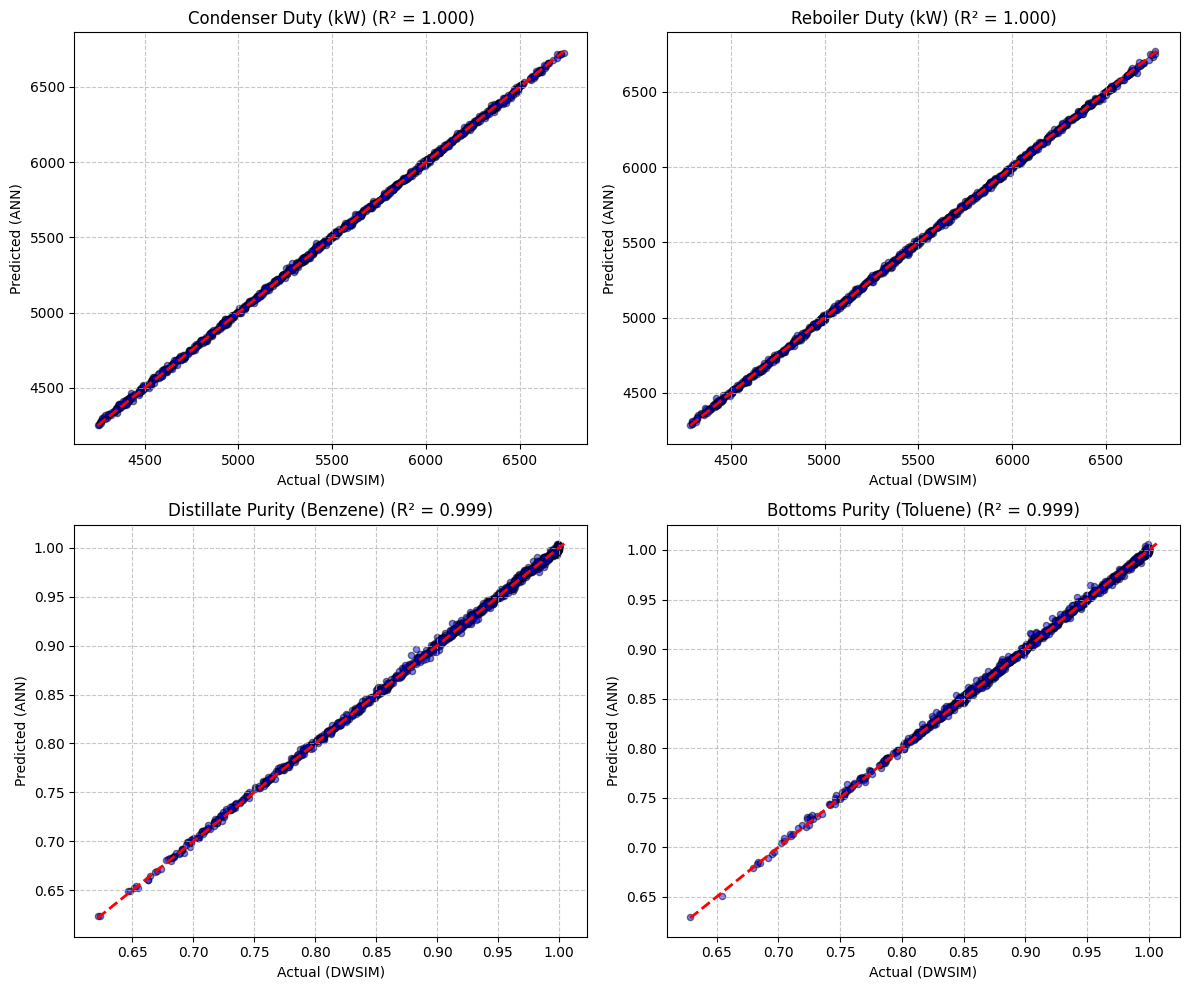

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

df = pd.read_csv('DWSIM_ML_Dataset_Final.csv')

X = df[['Feed_T', 'Feed_P', 'x_F(B)', 'Stages', 'Feed_Stage', 'RR', 'W']]
Y = df[['Qc_kW', 'Qr_kW', 'x_D(B)', 'x_W(T)']]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
Y_train_scaled = scaler_Y.fit_transform(Y_train)

X_test_scaled = scaler_X.transform(X_test)
Y_test_scaled = scaler_Y.transform(Y_test)

param_grid = {
    'hidden_layer_sizes': [(64, 32), (100, 50), (128, 64, 32)],
    'activation': ['relu', 'tanh'],
    'alpha': [1e-4, 1e-3],          
    'learning_rate_init': [1e-3, 1e-2],    
}

mlp = MLPRegressor(solver='adam', max_iter=2000, random_state=13, early_stopping=True)

print("Initiating 5-Fold Grid Search on Training Data...")
grid = GridSearchCV(mlp, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid.fit(X_train_scaled, Y_train_scaled)

best_model = grid.best_estimator_
print(f"\nBest MLP Architecture: {grid.best_params_}")

print("\nEvaluating model on 20% Unseen Test Set...")
Y_pred_scaled = best_model.predict(X_test_scaled)

Y_test_orig = scaler_Y.inverse_transform(Y_test_scaled)
Y_pred_orig = scaler_Y.inverse_transform(Y_pred_scaled)

r2_all = r2_score(Y_test_orig, Y_pred_orig, multioutput='raw_values')
rmse_all = np.sqrt(mean_squared_error(Y_test_orig, Y_pred_orig, multioutput='raw_values'))
mae_all = mean_absolute_error(Y_test_orig, Y_pred_orig, multioutput='raw_values')

output_names = ['Condenser Duty (kW)', 'Reboiler Duty (kW)', 'Distillate Purity (Benzene)', 'Bottoms Purity (Toluene)']

print("\n--- FINAL METRICS ON UNSEEN DATA ---")
for i, name in enumerate(output_names):
    print(f"{name}:")
    print(f"  R^2  : {r2_all[i]:.4f}")
    print(f"  RMSE : {rmse_all[i]:.4f}")
    print(f"  MAE  : {mae_all[i]:.4f}\n")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(4):
    actual = Y_test_orig[:, i]
    predicted = Y_pred_orig[:, i]
    
    axes[i].scatter(actual, predicted, c='blue', alpha=0.5, edgecolor='k', s=20)
    
    min_val = min(np.min(actual), np.min(predicted))
    max_val = max(np.max(actual), np.max(predicted))
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    axes[i].set_title(f'{output_names[i]} (R² = {r2_all[i]:.3f})')
    axes[i].set_xlabel('Actual (DWSIM)')
    axes[i].set_ylabel('Predicted (ANN)')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
import joblib

joblib.dump(best_model, 'SRK_Distillation_MLP.pkl')

joblib.dump(scaler_X, 'Scaler_X.pkl')
joblib.dump(scaler_Y, 'Scaler_Y.pkl')

print("Model and Scalers successfully saved to disk.")

Model and Scalers successfully saved to disk.


Training Multi-Output Random Forest Regressor...

Evaluating model on 20% Unseen Test Set...

--- FINAL RF METRICS ON UNSEEN DATA ---
Condenser Duty (kW):
  R^2  : 0.9976
  RMSE : 32.5215
  MAE  : 26.1126

Reboiler Duty (kW):
  R^2  : 0.9985
  RMSE : 25.7289
  MAE  : 20.6203

Distillate Purity (Benzene):
  R^2  : 0.8880
  RMSE : 0.0312
  MAE  : 0.0252

Bottoms Purity (Toluene):
  R^2  : 0.8009
  RMSE : 0.0338
  MAE  : 0.0292

Random Forest Model successfully saved to disk.


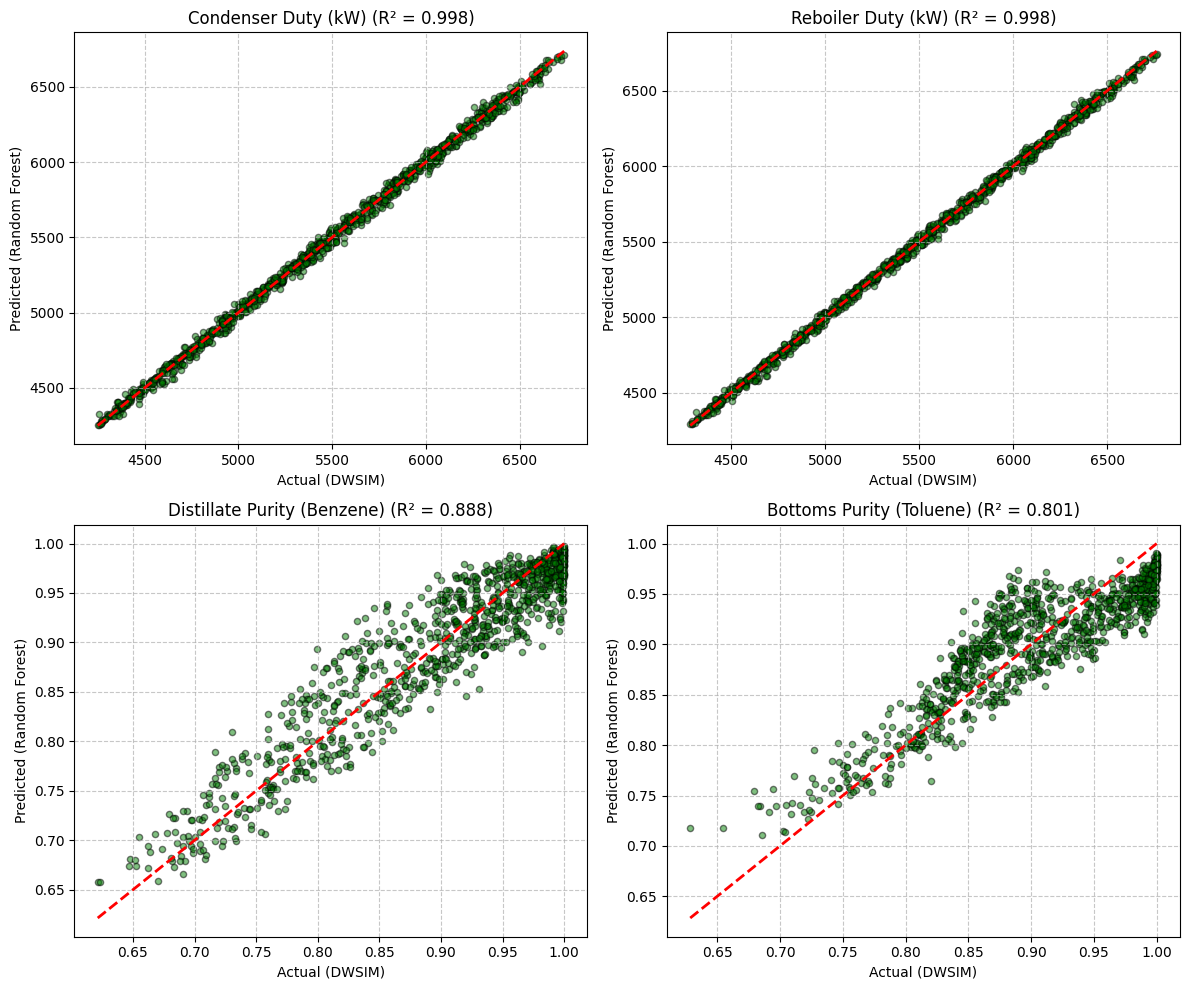

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor 
import joblib

df = pd.read_csv('DWSIM_ML_Dataset_Final.csv')

X = df[['Feed_T', 'Feed_P', 'x_F(B)', 'Stages', 'Feed_Stage', 'RR', 'W']]
Y = df[['Qc_kW', 'Qr_kW', 'x_D(B)', 'x_W(T)']]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Training Multi-Output Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=150, max_depth=20, random_state=42, n_jobs=-1)

rf_model.fit(X_train, Y_train)

print("\nEvaluating model on 20% Unseen Test Set...")
Y_pred = rf_model.predict(X_test)

Y_test_np = Y_test.values

r2_all = r2_score(Y_test_np, Y_pred, multioutput='raw_values')
rmse_all = np.sqrt(mean_squared_error(Y_test_np, Y_pred, multioutput='raw_values'))
mae_all = mean_absolute_error(Y_test_np, Y_pred, multioutput='raw_values')

output_names = ['Condenser Duty (kW)', 'Reboiler Duty (kW)', 'Distillate Purity (Benzene)', 'Bottoms Purity (Toluene)']

print("\n--- FINAL RF METRICS ON UNSEEN DATA ---")
for i, name in enumerate(output_names):
    print(f"{name}:")
    print(f"  R^2  : {r2_all[i]:.4f}")
    print(f"  RMSE : {rmse_all[i]:.4f}")
    print(f"  MAE  : {mae_all[i]:.4f}\n")

joblib.dump(rf_model, 'SRK_Distillation_RF.pkl')
print("Random Forest Model successfully saved to disk.")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(4):
    actual = Y_test_np[:, i]
    predicted = Y_pred[:, i]
    
    axes[i].scatter(actual, predicted, c='green', alpha=0.5, edgecolor='k', s=20)
    
    min_val = min(np.min(actual), np.min(predicted))
    max_val = max(np.max(actual), np.max(predicted))
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    axes[i].set_title(f'{output_names[i]} (R² = {r2_all[i]:.3f})')
    axes[i].set_xlabel('Actual (DWSIM)')
    axes[i].set_ylabel('Predicted (Random Forest)')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Initiating Randomized SVR Search (8 Iterations)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best SVR Parameters: {'C': 50, 'cache_size': 200, 'coef0': 0.0, 'degree': 3, 'epsilon': 0.05, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Evaluating best model on 20% Unseen Test Set...

--- FINAL RANDOM-SEARCHED SVR METRICS ---
Condenser Duty (kW):
  R^2  : 0.9979
  RMSE : 30.0636
  MAE  : 20.1072

Reboiler Duty (kW):
  R^2  : 0.9980
  RMSE : 29.7426
  MAE  : 19.8783

Distillate Purity (Benzene):
  R^2  : 0.9951
  RMSE : 0.0065
  MAE  : 0.0050

Bottoms Purity (Toluene):
  R^2  : 0.9933
  RMSE : 0.0062
  MAE  : 0.0047

Optimized SVR Model saved to disk.


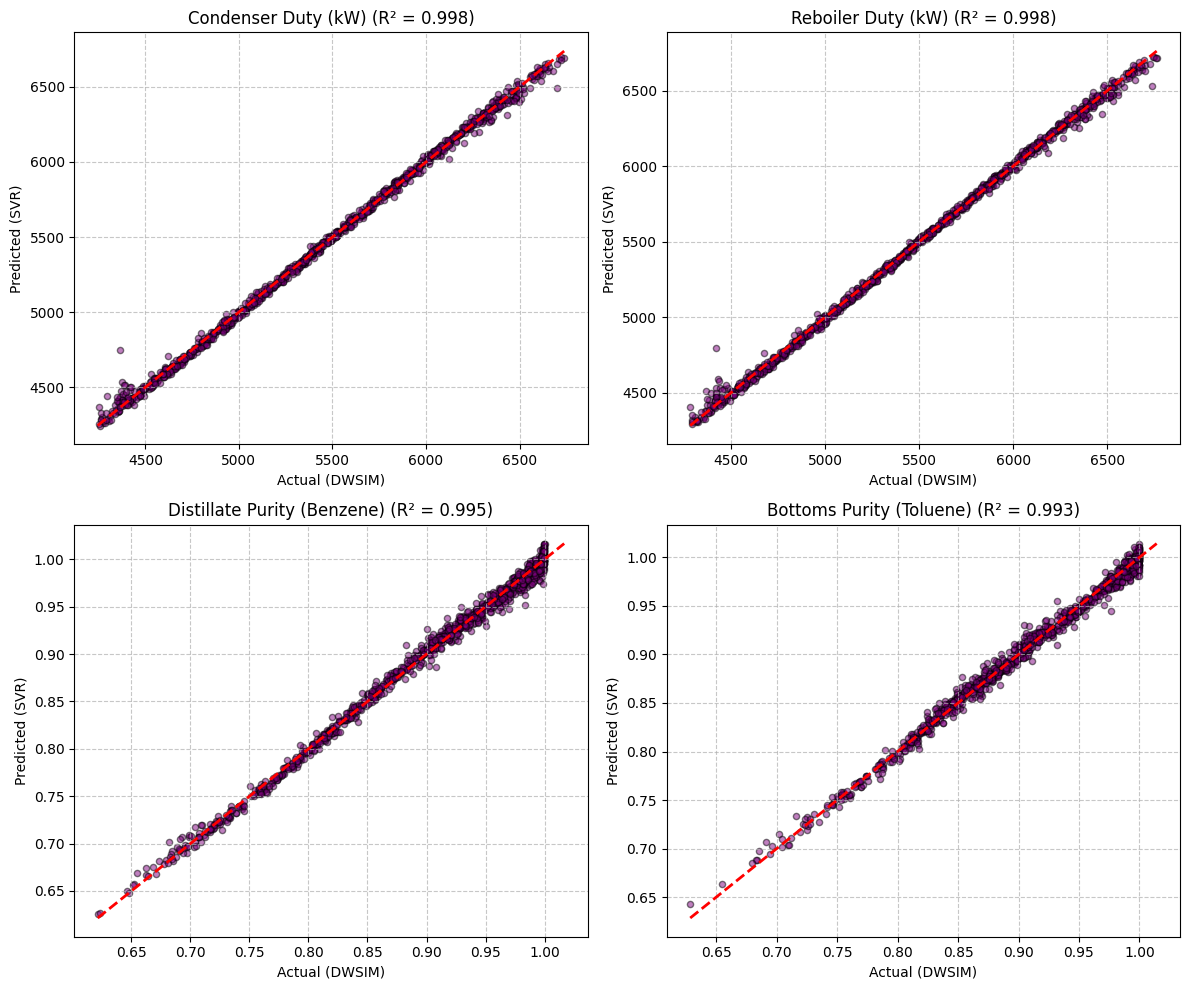

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
import joblib

df = pd.read_csv('DWSIM_ML_Dataset_Final.csv')

X = df[['Feed_T', 'Feed_P', 'x_F(B)', 'Stages', 'Feed_Stage', 'RR', 'W']]
Y = df[['Qc_kW', 'Qr_kW', 'x_D(B)', 'x_W(T)']]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
Y_train_scaled = scaler_Y.fit_transform(Y_train)

X_test_scaled = scaler_X.transform(X_test)
Y_test_scaled = scaler_Y.transform(Y_test)

base_svr = SVR(kernel='rbf')
multi_svr = MultiOutputRegressor(base_svr)

param_dist = {
    'estimator__C': [10, 50, 100, 200],
    'estimator__gamma': ['scale', 0.01, 0.1],
    'estimator__epsilon': [0.01, 0.05, 0.1]
}

print("Initiating Randomized SVR Search (8 Iterations)...")

random_search = RandomizedSearchCV(
    multi_svr, 
    param_distributions=param_dist, 
    n_iter=8, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1, 
    verbose=2,
    random_state=42
)

random_search.fit(X_train_scaled, Y_train_scaled)

best_model = random_search.best_estimator_
print(f"\nBest SVR Parameters: {best_model.estimators_[0].get_params()}")

print("\nEvaluating best model on 20% Unseen Test Set...")
Y_pred_scaled = best_model.predict(X_test_scaled)

Y_test_orig = scaler_Y.inverse_transform(Y_test_scaled)
Y_pred_orig = scaler_Y.inverse_transform(Y_pred_scaled)

r2_all = r2_score(Y_test_orig, Y_pred_orig, multioutput='raw_values')
rmse_all = np.sqrt(mean_squared_error(Y_test_orig, Y_pred_orig, multioutput='raw_values'))
mae_all = mean_absolute_error(Y_test_orig, Y_pred_orig, multioutput='raw_values')

output_names = ['Condenser Duty (kW)', 'Reboiler Duty (kW)', 'Distillate Purity (Benzene)', 'Bottoms Purity (Toluene)']

print("\n--- FINAL RANDOM-SEARCHED SVR METRICS ---")
for i, name in enumerate(output_names):
    print(f"{name}:")
    print(f"  R^2  : {r2_all[i]:.4f}")
    print(f"  RMSE : {rmse_all[i]:.4f}")
    print(f"  MAE  : {mae_all[i]:.4f}\n")

joblib.dump(best_model, 'SRK_Distillation_SVR_Optimized.pkl')
print("Optimized SVR Model saved to disk.")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i in range(4):
    actual = Y_test_orig[:, i]
    predicted = Y_pred_orig[:, i]
    
    axes[i].scatter(actual, predicted, c='purple', alpha=0.5, edgecolor='k', s=20)
    
    min_val = min(np.min(actual), np.min(predicted))
    max_val = max(np.max(actual), np.max(predicted))
    axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    axes[i].set_title(f'{output_names[i]} (R² = {r2_all[i]:.3f})')
    axes[i].set_xlabel('Actual (DWSIM)')
    axes[i].set_ylabel('Predicted (SVR)')
    axes[i].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()
plt.show()